In [1]:
import numpy as np
import os 
os.environ['KERAS_BACKEND'] = 'torch'
import keras
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from models.ffnn import ffnn
import pandas as pd

In [2]:
cpi = pd.read_csv('..\\data\\structured_data\\CPI_growth_yoy_dataframe.csv')
rgdp = pd.read_csv('..\\data\\structured_data\\RGDP_growth_dataframe.csv')
unemp = pd.read_csv('..\\data\\structured_data\\unemployment_rate_dataframe.csv')
# dropping the unwanted duplicate columns and indexes, renaming the observed value columns
cpi = cpi.drop(['Unnamed: 0'], axis = 1).rename(columns = {'OBS_VALUE': 'CPI inflation'})
rgdp = rgdp.drop(['Unnamed: 0', 'Reference area', 'TIME_PERIOD'], axis = 1).rename(columns = {'OBS_VALUE': 'RGDP growth'})
unemp = unemp.drop(['Unnamed: 0', 'Reference area', 'TIME_PERIOD'], axis = 1).rename(columns = {'OBS_VALUE': 'Unemp rate'})
# concatenating along the columns
df = pd.concat((cpi, rgdp, unemp), axis = 1)

In [3]:
model = ffnn(df, column_names_to_difference = ['CPI inflation', 'Unemp rate'], train_years = [1994, 2009], 
            val_years = [2010, 2014], test_years = [2015, 2019])

best config is:
1st hidden layer neurons: 32
2nd hidden layer neurons 16
dropout rate: 0.2
batch size is: 16
minimum validation loss reached: 0.6207308173179626
reached after 17 epochs

Fitting the model on validation data...
best config is:
1st hidden layer neurons: 16
2nd hidden layer neurons 16
dropout rate: 0.1
batch size is: 16
minimum validation loss reached: 0.6076315641403198
reached after 43 epochs


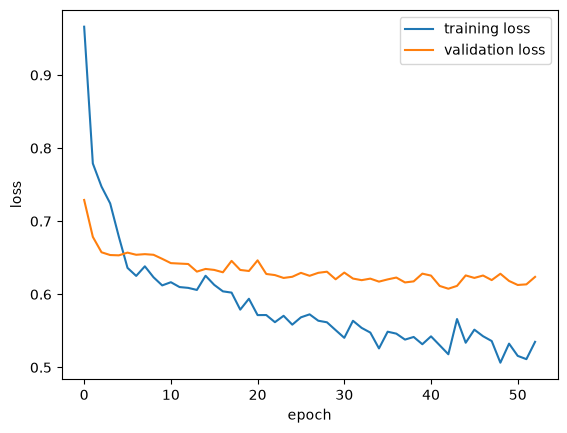

starting rolling-origin forecast...
Epoch 1/43
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5791
Epoch 2/43
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6005
Epoch 3/43
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5802
Epoch 4/43
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5903
Epoch 5/43
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5810
Epoch 6/43
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5890
Epoch 7/43
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5719
Epoch 8/43
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5683
Epoch 9/43
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5570
Epoch 10/43
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5768
Epoch 11/43
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5515
Epoch 12/43
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5956
Epoch 13/43
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5862
Epoch 14/43
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5653
Epoch 15/43
110/110 ━

In [4]:
df = model.rolling_origin_forecast()

Fitting the model on validation data...
best config is:
1st hidden layer neurons: 16
2nd hidden layer neurons 16
dropout rate: 0.1
batch size is: 16
minimum validation loss reached: 0.6076315641403198
reached after 43 epochs

In [12]:
df

,Reference area,TIME_PERIOD,Unemp rate,Forecasts
84,Australia,2015-Q1,6.202810,6.317583
85,Australia,2015-Q2,6.016903,6.173287
86,Australia,2015-Q3,6.178764,5.979604
87,Australia,2015-Q4,5.834710,6.061275
88,Australia,2016-Q1,5.796363,5.706007
...,...,...,...,...
2283,United States,2018-Q4,3.833333,3.669032
2284,United States,2019-Q1,3.866667,3.858368
2285,United States,2019-Q2,3.633333,3.858864
2286,United States,2019-Q3,3.600000,3.569047


In [13]:
df.to_csv('..\\data\\forecasts\\ffnn_forecasts_dataframe.csv')